# TEM Projector Simplified Zoom Model (No DAC)

This notebook uses the simplified projector model path in `temgym_core.projector_model`.

It ignores DAC curves and solves directly from:

- approximate geometry distances,
- strong objective and projector lenses (`~2 mm` focal length),
- weaker IL1/IL2/IL3 zoom-lens behavior,
- constraints on magnification, `B = 0`, and zero image rotation.


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

def _propagation_matrix_np(z: float) -> np.ndarray:
    return np.array(
        [[1.0, z, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]],
        dtype=float,
    )


def _lens_matrix_np(f: float) -> np.ndarray:
    return np.array(
        [[1.0, 0.0, 0.0], [-1.0 / f, 1.0, 0.0], [0.0, 0.0, 1.0]],
        dtype=float,
    )


def _build_abcd_np(dists: np.ndarray, focals: np.ndarray) -> np.ndarray:
    mtx = _propagation_matrix_np(float(dists[-1]))
    for i in reversed(range(len(focals))):
        mtx = mtx @ _lens_matrix_np(float(focals[i]))
        mtx = mtx @ _propagation_matrix_np(float(dists[i]))
    return mtx


%matplotlib widget


## Targets And Geometry

Edit distances below to your approximate column geometry.


In [2]:
def load_raw_dac_hex_from_notebook(path: Path) -> dict:
    import ast
    nb = json.loads(path.read_text())
    for cell in nb['cells']:
        if cell.get('cell_type') != 'code':
            continue
        src = ''.join(cell.get('source', []))
        if 'RAW_DAC_HEX =' not in src:
            continue

        lines = src.splitlines()
        start = None
        for i, line in enumerate(lines):
            if line.strip().startswith('RAW_DAC_HEX ='):
                start = i
                break
        if start is None:
            continue

        buf = []
        brace_balance = 0
        for j in range(start, len(lines)):
            if j == start:
                part = lines[j][lines[j].find('{'):]
            else:
                part = lines[j]
            brace_balance += part.count('{') - part.count('}')
            buf.append(part)
            if brace_balance == 0:
                break

        return ast.literal_eval('\n'.join(buf))

    raise RuntimeError(f'RAW_DAC_HEX not found in {path}')


LENS = ['IL1', 'IL2', 'IL3', 'PL1']
raw_hex_path = Path('../lens_inversion/dac_lens_inversion.ipynb')
RAW_DAC_HEX = load_raw_dac_hex_from_notebook(raw_hex_path)

ALL_MAGS = np.array(sorted(int(k) for k in RAW_DAC_HEX.keys()), dtype=float)
ALL_CURRENTS = np.array(
    [[int(RAW_DAC_HEX[str(int(m))][ln], 16) for ln in LENS] for m in ALL_MAGS],
    dtype=float,
)

# Fit in Band C high range (where the trend is cleanest).
FIT_MAG_MIN = 80000.0
FIT_MAG_MAX = 600000.0
fit_mask = (ALL_MAGS >= FIT_MAG_MIN) & (ALL_MAGS <= FIT_MAG_MAX)
FIT_MAGS = ALL_MAGS[fit_mask]
FIT_CURRENTS = ALL_CURRENTS[fit_mask]

print('Loaded DAC points:', len(ALL_MAGS))
print('Fit band:', FIT_MAG_MIN, 'to', FIT_MAG_MAX)
print('Fit points:', len(FIT_MAGS))
print('Current curves are locked to DAC hex values (exact match).')


Loaded DAC points: 31
Fit band: 80000.0 to 600000.0
Fit points: 10
Current curves are locked to DAC hex values (exact match).


## Solve Simplified Projector Zoom Model

Defaults enforce strong OPL/PL (`2 mm`) and weaker IL lenses.

If many settings are marked unsuccessful, relax/tune:

- geometry distances,
- `il_current_bounds_at`,
- `weak_min_ratio`,
- `max_nfev`.


In [3]:
# Unknowns:
# d1..d5     : drifts [OPL->IL1, IL1->IL2, IL2->IL3, IL3->PL1, PL1->detector]
# f_opl      : objective/projector strong-lens focal (shared in this simplified stack)
# Cf_il      : shared IL strength for IL1=IL2=IL3
# Cf_pl      : PL1 strength
# d0 fixed   : object->OPL drift

D0_OBJECT_TO_OPL_M = 2.0e-3


def decode_x(x: np.ndarray):
    d = np.exp(x[:5])
    f_opl = float(np.exp(x[5]))
    cf_il = float(np.exp(x[6]))
    cf_pl = float(np.exp(x[7]))
    return d, f_opl, cf_il, cf_pl


def forward_from_currents(mags: np.ndarray, currents: np.ndarray, x: np.ndarray):
    d_var, f_opl, cf_il, cf_pl = decode_x(x)
    dists = np.array([D0_OBJECT_TO_OPL_M, *d_var], dtype=float)

    A_abs = []
    B_vals = []
    f_il_rows = []
    f_pl_rows = []

    for i1, i2, i3, ipl in currents:
        f1 = 1.0 / max(cf_il * i1 * i1, 1e-30)
        f2 = 1.0 / max(cf_il * i2 * i2, 1e-30)
        f3 = 1.0 / max(cf_il * i3 * i3, 1e-30)
        fp = 1.0 / max(cf_pl * ipl * ipl, 1e-30)

        mtx = _build_abcd_np(
            dists=dists,
            focals=np.array([f_opl, f1, f2, f3, fp], dtype=float),
        )
        A_abs.append(abs(float(mtx[0, 0])))
        B_vals.append(float(mtx[0, 1]))
        f_il_rows.append([f1, f2, f3])
        f_pl_rows.append(fp)

    return {
        'dists_m': dists,
        'A_abs': np.array(A_abs, dtype=float),
        'B_m': np.array(B_vals, dtype=float),
        'f_il_m': np.array(f_il_rows, dtype=float),
        'f_pl_m': np.array(f_pl_rows, dtype=float),
    }


def residual_equal_il(x: np.ndarray) -> np.ndarray:
    out = forward_from_currents(FIT_MAGS, FIT_CURRENTS, x)
    A = out['A_abs']
    B = out['B_m']
    f_il = out['f_il_m'].reshape(-1)
    f_pl = out['f_pl_m']
    total_len = max(float(np.sum(out['dists_m'])), 1e-12)

    r = []

    # Match magnification shape across band C.
    r.extend(np.log(A[1:] / A[0]) - np.log(FIT_MAGS[1:] / FIT_MAGS[0]))

    # Keep image plane close to focus.
    r.extend(3.0 * B / total_len)

    # Soft physical priors.
    r.extend(0.2 * np.clip(1e-3 - f_il, 0.0, np.inf) / 1e-3)
    r.extend(0.2 * np.clip(f_il - 100e-3, 0.0, np.inf) / 100e-3)
    r.extend(0.4 * np.clip(1e-3 - f_pl, 0.0, np.inf) / 1e-3)
    r.extend(0.4 * np.clip(f_pl - 10e-3, 0.0, np.inf) / 10e-3)

    return np.array(r, dtype=float)


# Seed from a good solution found for this DAC band.
x0 = np.log(np.array([
    0.0588,   # d1
    0.3500,   # d2
    0.0200,   # d3
    0.0321,   # d4
    0.0200,   # d5
    0.00193,  # f_opl
    1.09e-7,  # Cf_il (shared IL)
    2.44e-8,  # Cf_pl
], dtype=float))

lb = np.log(np.array([
    0.020, 0.020, 0.020, 0.020, 0.020,
    0.0008,
    1e-12,
    1e-12,
], dtype=float))
ub = np.log(np.array([
    0.350, 0.350, 0.350, 0.350, 0.350,
    0.0050,
    1e-4,
    1e-4,
], dtype=float))

sol = least_squares(
    residual_equal_il,
    x0,
    bounds=(lb, ub),
    loss='soft_l1',
    max_nfev=5000,
)

fit_out = forward_from_currents(FIT_MAGS, FIT_CURRENTS, sol.x)
DISTS_M = fit_out['dists_m']
A_FIT_ABS = fit_out['A_abs']
B_FIT_M = fit_out['B_m']
F_IL_FIT_M = fit_out['f_il_m']
F_PL_FIT_M = fit_out['f_pl_m']

D_VAR_M, F_OPL_M, CF_IL_SHARED, CF_PL1 = decode_x(sol.x)
MAG_SCALE = float(np.median(A_FIT_ABS / FIT_MAGS))
A_FIT_SCALED = A_FIT_ABS / MAG_SCALE

print('Solve success:', bool(sol.success), '| nfev:', int(sol.nfev), '| cost:', float(sol.cost))
print('Shared IL strength enforced: IL1 == IL2 == IL3')
print('dists [mm]:', np.round(1e3 * DISTS_M, 3))
print('f_opl [mm]:', 1e3 * F_OPL_M)
print('Cf_il_shared:', CF_IL_SHARED)
print('Cf_pl1:', CF_PL1)
print('mag_scale:', MAG_SCALE)


Solve success: True | nfev: 97 | cost: 0.00763837360094799
Shared IL strength enforced: IL1 == IL2 == IL3
dists [mm]: [  2.     69.493 350.     20.     32.294  20.   ]
f_opl [mm]: 1.9396665152406998
Cf_il_shared: 1.0893734095785013e-07
Cf_pl1: 2.4412226441782398e-08
mag_scale: 0.02542012469045074


## Fit Table Diagnostics


In [4]:
err_fit_pct = 100.0 * (A_FIT_SCALED - FIT_MAGS) / FIT_MAGS
ratio_err_fit_pct = 100.0 * ((A_FIT_SCALED / A_FIT_SCALED[0]) / (FIT_MAGS / FIT_MAGS[0]) - 1.0)

print('Fit-band metrics (80k-600k):')
print('  median |mag error| [%]:', float(np.median(np.abs(err_fit_pct))))
print('  max |mag error| [%]:', float(np.max(np.abs(err_fit_pct))))
print('  median |ratio error| [%]:', float(np.median(np.abs(ratio_err_fit_pct))))
print('  max |ratio error| [%]:', float(np.max(np.abs(ratio_err_fit_pct))))
print('  max |B| [mm]:', float(np.max(np.abs(B_FIT_M)) * 1e3))
print('  IL focal range [mm]:', float(np.min(F_IL_FIT_M) * 1e3), 'to', float(np.max(F_IL_FIT_M) * 1e3))
print('  PL1 focal range [mm]:', float(np.min(F_PL_FIT_M) * 1e3), 'to', float(np.max(F_PL_FIT_M) * 1e3))

# Build a compact row table for plotting/reporting.
rows = []
for i, m in enumerate(FIT_MAGS):
    rows.append(
        {
            'magnification_target': float(m),
            'magnification_predicted': float(A_FIT_SCALED[i]),
            'magnification_error_pct': float(err_fit_pct[i]),
            'B': float(B_FIT_M[i]),
            'I0_IL1_at': float(FIT_CURRENTS[i, 0]),
            'I0_IL2_at': float(FIT_CURRENTS[i, 1]),
            'I0_IL3_at': float(FIT_CURRENTS[i, 2]),
            'I0_PL1_at': float(FIT_CURRENTS[i, 3]),
            'f_IL1_m': float(F_IL_FIT_M[i, 0]),
            'f_IL2_m': float(F_IL_FIT_M[i, 1]),
            'f_IL3_m': float(F_IL_FIT_M[i, 2]),
            'f_PL1_m': float(F_PL_FIT_M[i]),
        }
    )

# Trend check in Band C.
idx = np.arange(len(rows), dtype=float)
i1 = np.array([r['I0_IL1_at'] for r in rows], dtype=float)
i2 = np.array([r['I0_IL2_at'] for r in rows], dtype=float)
i3 = np.array([r['I0_IL3_at'] for r in rows], dtype=float)
print('Band-C slopes [DAC-step]: IL1=', float(np.polyfit(idx, i1, 1)[0]),
      'IL2=', float(np.polyfit(idx, i2, 1)[0]),
      'IL3=', float(np.polyfit(idx, i3, 1)[0]))


Fit-band metrics (80k-600k):
  median |mag error| [%]: 2.5161244581534117
  max |mag error| [%]: 6.842294105025096
  median |ratio error| [%]: 2.8787901313084676
  max |ratio error| [%]: 7.449008372402011
  max |B| [mm]: 0.5871916213102679
  IL focal range [mm]: 3.6544198001673847 to 90.04062835007943
  PL1 focal range [mm]: 10.00075210600802 to 10.00075210600802
Band-C slopes [DAC-step]: IL1= -113.0121212121201 IL2= 2294.666666666666 IL3= -2306.4848484848458


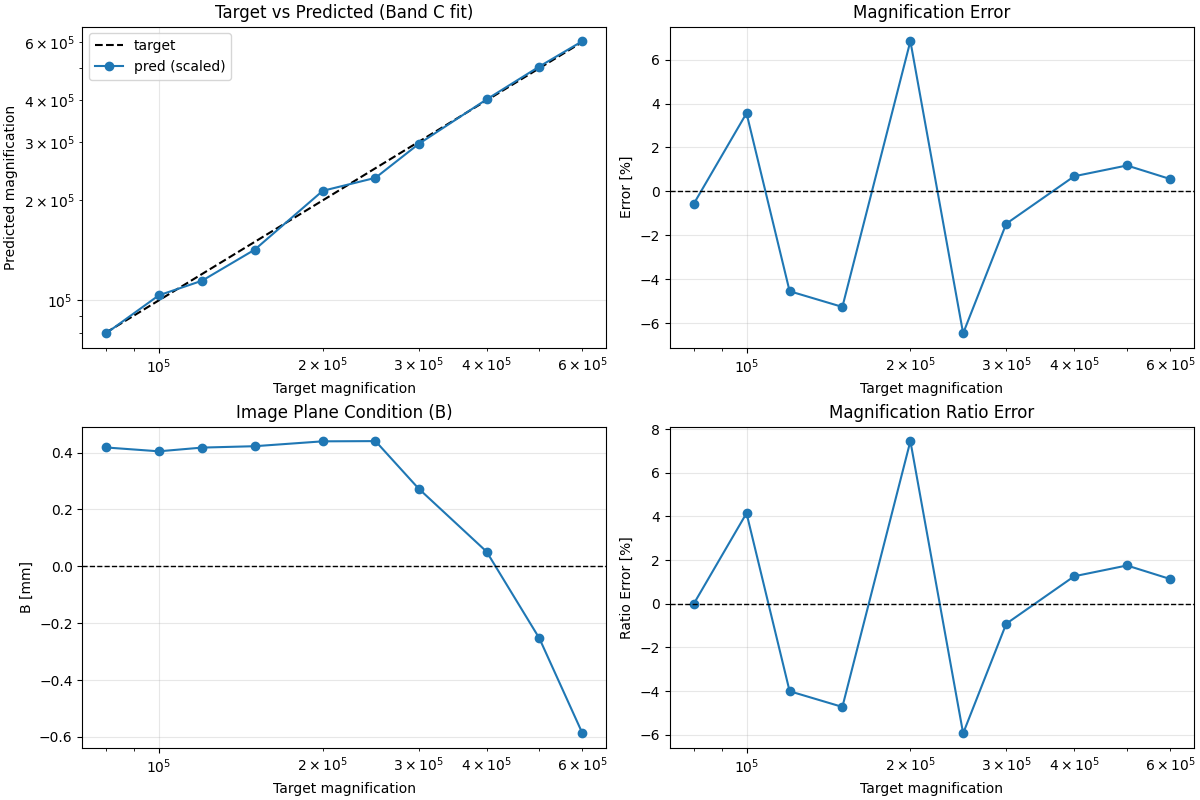

In [5]:
m_target = np.array([r['magnification_target'] for r in rows], dtype=float)
m_pred = np.array([r['magnification_predicted'] for r in rows], dtype=float)
err_pct = np.array([r['magnification_error_pct'] for r in rows], dtype=float)
B_vals = np.array([r['B'] for r in rows], dtype=float)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axs[0, 0].plot(m_target, m_target, 'k--', label='target')
axs[0, 0].plot(m_target, m_pred, 'o-', label='pred (scaled)')
axs[0, 0].set_xscale('log')
axs[0, 0].set_yscale('log')
axs[0, 0].set_xlabel('Target magnification')
axs[0, 0].set_ylabel('Predicted magnification')
axs[0, 0].set_title('Target vs Predicted (Band C fit)')
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

axs[0, 1].plot(m_target, err_pct, 'o-')
axs[0, 1].axhline(0.0, color='k', lw=1, ls='--')
axs[0, 1].set_xscale('log')
axs[0, 1].set_xlabel('Target magnification')
axs[0, 1].set_ylabel('Error [%]')
axs[0, 1].set_title('Magnification Error')
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].plot(m_target, 1e3 * B_vals, 'o-')
axs[1, 0].axhline(0.0, color='k', lw=1, ls='--')
axs[1, 0].set_xscale('log')
axs[1, 0].set_xlabel('Target magnification')
axs[1, 0].set_ylabel('B [mm]')
axs[1, 0].set_title('Image Plane Condition (B)')
axs[1, 0].grid(True, alpha=0.3)

ratio_err_fit = 100.0 * ((m_pred / m_pred[0]) / (m_target / m_target[0]) - 1.0)
axs[1, 1].plot(m_target, ratio_err_fit, 'o-')
axs[1, 1].axhline(0.0, color='k', lw=1, ls='--')
axs[1, 1].set_xscale('log')
axs[1, 1].set_xlabel('Target magnification')
axs[1, 1].set_ylabel('Ratio Error [%]')
axs[1, 1].set_title('Magnification Ratio Error')
axs[1, 1].grid(True, alpha=0.3)

plt.show()


## Lens Current Curves


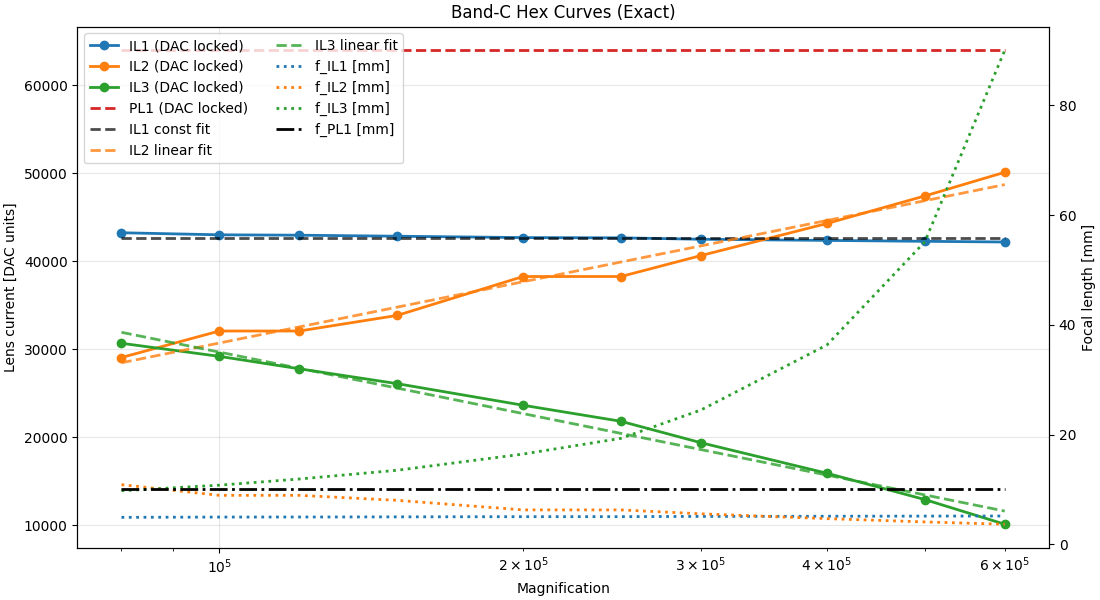

In [6]:
# Compare locked curves to the raw DAC curves (they overlap exactly by construction).
m_vals = FIT_MAGS.copy()
i_il1 = FIT_CURRENTS[:, 0]
i_il2 = FIT_CURRENTS[:, 1]
i_il3 = FIT_CURRENTS[:, 2]
i_pl1 = FIT_CURRENTS[:, 3]

f_il1_mm = 1e3 * F_IL_FIT_M[:, 0]
f_il2_mm = 1e3 * F_IL_FIT_M[:, 1]
f_il3_mm = 1e3 * F_IL_FIT_M[:, 2]
f_pl1_mm = 1e3 * F_PL_FIT_M

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
ax.plot(m_vals, i_il1, 'o-', lw=2, label='IL1 (DAC locked)')
ax.plot(m_vals, i_il2, 'o-', lw=2, label='IL2 (DAC locked)')
ax.plot(m_vals, i_il3, 'o-', lw=2, label='IL3 (DAC locked)')
ax.plot(m_vals, i_pl1, '--', lw=2, label='PL1 (DAC locked)')

x_log = np.log10(m_vals)
ax.plot(m_vals, np.full_like(i_il1, np.mean(i_il1)), 'k--', lw=2, alpha=0.7, label='IL1 const fit')
ax.plot(m_vals, np.polyval(np.polyfit(x_log, i_il2, 1), x_log), color='C1', ls='--', lw=2, alpha=0.8, label='IL2 linear fit')
ax.plot(m_vals, np.polyval(np.polyfit(x_log, i_il3, 1), x_log), color='C2', ls='--', lw=2, alpha=0.8, label='IL3 linear fit')

ax.set_xscale('log')
ax.set_xlabel('Magnification')
ax.set_ylabel('Lens current [DAC units]')
ax.set_title('Band-C Hex Curves (Exact)')
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
ax2.plot(m_vals, f_il1_mm, color='C0', ls=':', lw=2, label='f_IL1 [mm]')
ax2.plot(m_vals, f_il2_mm, color='C1', ls=':', lw=2, label='f_IL2 [mm]')
ax2.plot(m_vals, f_il3_mm, color='C2', ls=':', lw=2, label='f_IL3 [mm]')
ax2.plot(m_vals, f_pl1_mm, color='k', ls='-.', lw=2, label='f_PL1 [mm]')
ax2.set_ylabel('Focal length [mm]')

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, ncol=2, loc='upper left')

plt.show()


## Realize A Specific Magnification


In [7]:
requested_mag = 100000.0

# Interpolate DAC-locked currents on log-mag axis.
log_fit_m = np.log10(FIT_MAGS)
q = float(np.log10(np.clip(requested_mag, FIT_MAGS.min(), FIT_MAGS.max())))
I_req = np.array([
    np.interp(q, log_fit_m, FIT_CURRENTS[:, 0]),
    np.interp(q, log_fit_m, FIT_CURRENTS[:, 1]),
    np.interp(q, log_fit_m, FIT_CURRENTS[:, 2]),
    np.interp(q, log_fit_m, FIT_CURRENTS[:, 3]),
], dtype=float)

f1_req = 1.0 / max(CF_IL_SHARED * I_req[0] * I_req[0], 1e-30)
f2_req = 1.0 / max(CF_IL_SHARED * I_req[1] * I_req[1], 1e-30)
f3_req = 1.0 / max(CF_IL_SHARED * I_req[2] * I_req[2], 1e-30)
fp_req = 1.0 / max(CF_PL1 * I_req[3] * I_req[3], 1e-30)

mtx_req = _build_abcd_np(
    dists=DISTS_M,
    focals=np.array([F_OPL_M, f1_req, f2_req, f3_req, fp_req], dtype=float),
)
A_req_scaled = abs(float(mtx_req[0, 0])) / MAG_SCALE
B_req_mm = 1e3 * float(mtx_req[0, 1])

print('Requested mag:', requested_mag)
print('Interpolated DAC currents [IL1, IL2, IL3, PL1]:', I_req)
print('Predicted magnification (scaled):', A_req_scaled)
print('Predicted B [mm]:', B_req_mm)
print('Focals [mm] IL1/IL2/IL3/PL1:', 1e3 * np.array([f1_req, f2_req, f3_req, fp_req]))


Requested mag: 100000.0
Interpolated DAC currents [IL1, IL2, IL3, PL1]: [43008. 32070. 29189. 64000.]
Predicted magnification (scaled): 103559.95951256552
Predicted B [mm]: 0.4046057677342674
Focals [mm] IL1/IL2/IL3/PL1: [ 4.96277671  8.92535111 10.77419413 10.00075211]


## Build TemGym Components


In [8]:
print('Final fitted configuration (Band C, DAC-locked, equal IL strength):')
print('  d_object_to_opl [mm]:', 1e3 * D0_OBJECT_TO_OPL_M)
print('  d_opl_to_il1 [mm]:   ', 1e3 * DISTS_M[1])
print('  d_il1_to_il2 [mm]:   ', 1e3 * DISTS_M[2])
print('  d_il2_to_il3 [mm]:   ', 1e3 * DISTS_M[3])
print('  d_il3_to_pl1 [mm]:   ', 1e3 * DISTS_M[4])
print('  d_pl1_to_det [mm]:   ', 1e3 * DISTS_M[5])
print('  f_opl [mm]:          ', 1e3 * F_OPL_M)
print('  Cf_il_shared:        ', CF_IL_SHARED)
print('  Cf_pl1:              ', CF_PL1)


Final fitted configuration (Band C, DAC-locked, equal IL strength):
  d_object_to_opl [mm]: 2.0
  d_opl_to_il1 [mm]:    69.49326273731546
  d_il1_to_il2 [mm]:    349.9999999999999
  d_il2_to_il3 [mm]:    20.00000000000001
  d_il3_to_pl1 [mm]:    32.29383028677949
  d_pl1_to_det [mm]:    20.00000000000001
  f_opl [mm]:           1.9396665152406998
  Cf_il_shared:         1.0893734095785013e-07
  Cf_pl1:               2.4412226441782398e-08


## Quick Ray Plot


In [9]:
# This notebook variant is now focused on matching DAC hex curves with a constrained
# equal-IL-strength optical fit, so we skip ray-trace component visualization here.
print('Ray visualization skipped in DAC-locked mode.')


Ray visualization skipped in DAC-locked mode.


## Export / Reload


In [10]:
out_path = Path('../ray_transfer/exported_microscope_models/projector_hex_locked_equal_il_config.json')
out_path.parent.mkdir(parents=True, exist_ok=True)

payload = {
    'fit_band_mag_min': float(FIT_MAG_MIN),
    'fit_band_mag_max': float(FIT_MAG_MAX),
    'lens_names': LENS,
    'dists_m': [float(v) for v in DISTS_M],
    'f_opl_m': float(F_OPL_M),
    'cf_il_shared': float(CF_IL_SHARED),
    'cf_pl1': float(CF_PL1),
    'mag_scale': float(MAG_SCALE),
}

out_path.write_text(json.dumps(payload, indent=2))
print('Saved config to:', out_path)


Saved config to: ../ray_transfer/exported_microscope_models/projector_hex_locked_equal_il_config.json
